In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Прочитайте данные (переменную назовите 'df')

In [ ]:
Вывести несколько первых строк таблицы данных

In [4]:
df = pd.read_csv('data.csv')
df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


In [ ]:
Сразу переведем столбец \"Дата\" в правильный формат

In [6]:
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

In [ ]:
Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [12]:
grouped_df = (
    df.groupby('Дата', as_index=False)['Количество']
    .sum()
    .rename(columns={'Количество': 'Количество продаж'})
)

In [ ]:
Вывести несколько первых строк сгруппированных данных

In [13]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


In [ ]:
Нарисуйте график продаж у `grouped_df`

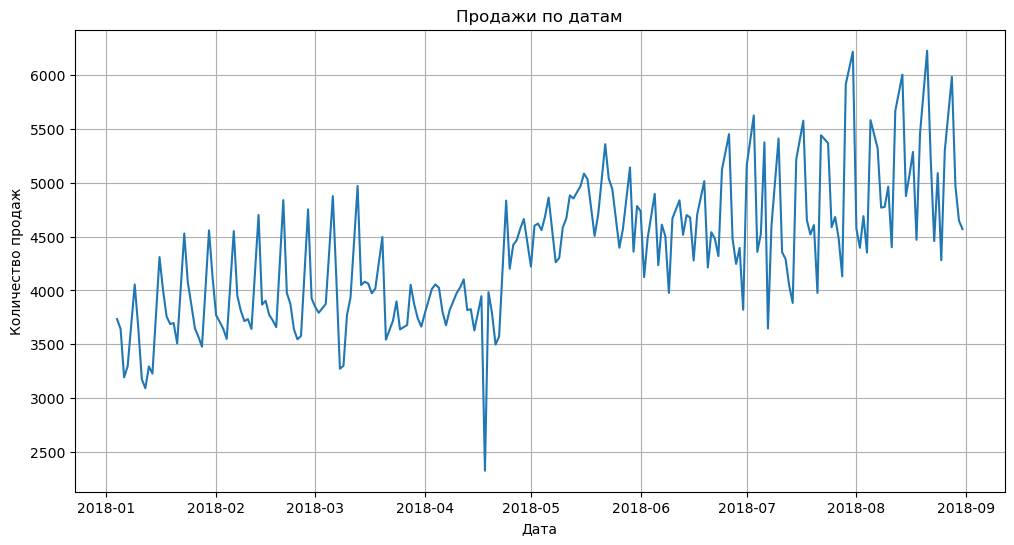

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    grouped_df['Дата'],
    grouped_df['Количество продаж']
)

plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.grid()

plt.show()

In [ ]:
На графике показано, как менялись продажи по датам

In [ ]:
В разные дни количество продаж отличается иногда продажи растут, иногда снижаются

In [ ]:
На графике есть резкие скачки вверх это дни с очень большими продажами Также есть дни, где продажи были ниже обычного

In [ ]:
Также есть дни где продажи были ниже обычного

In [ ]:
В целом видно, что продажи нестабильны и постоянно меняются со временем

In [ ]:
Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [15]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

In [ ]:
Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [16]:
mask = (
    (df['Склад'] == 3) &                          
    (df['Дата'].dt.month.isin([6, 7, 8])) &      
    (df['Дата'].dt.weekday == 2)                
)

filtered_df = df[mask]

In [17]:
top_products = (
    filtered_df.groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
)

In [18]:
top_products.head(1)

Номенклатура
product_1    2267
Name: Количество, dtype: int64

In [ ]:
Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, 
чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`,
и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [19]:
df['Дата'].min()

Timestamp('2018-01-04 00:00:00')

In [20]:
df['Дата'].max()

Timestamp('2018-08-31 00:00:00')

In [25]:
weather = pd.read_csv(
    'weather.csv.gz',
    sep=';',
    encoding='cp1251',
    skiprows=6
)

weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,70 – 80%.,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,100%.,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [26]:
weather.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

In [27]:
weather['Дата'] = pd.to_datetime(
    weather['Местное время в Астане'],
    dayfirst=True
)

weather['Дата'] = weather['Дата'].dt.date
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

In [28]:
weather_daily = (
    weather.groupby('Дата', as_index=False)['T']
    .mean()
)

weather_daily.head()

,Дата,T
0,1969-12-31,739.311782
1,1970-01-01,727.900161


In [38]:
weather['Местное время в Астане'].head(10)

31.08.2018 23:00     8.2
31.08.2018 20:00     9.6
31.08.2018 17:00    11.3
31.08.2018 14:00    12.3
31.08.2018 11:00    13.2
31.08.2018 08:00    12.5
31.08.2018 05:00    10.3
31.08.2018 02:00    10.8
30.08.2018 23:00    11.1
30.08.2018 20:00    17.1
Name: Местное время в Астане, dtype: float64

In [39]:
weather['Местное время в Астане'] = (
    weather['Местное время в Астане']
    .astype(str)
    .str.replace('\n', ' ')
    .str.strip()
)

In [40]:
weather['Дата'] = pd.to_datetime(
    weather['Местное время в Астане'],
    dayfirst=True,
    errors='coerce'
)

C:\Users\рс\AppData\Local\Temp\ipykernel_28924\2044869730.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather['Дата'] = pd.to_datetime(


In [41]:
weather = weather.dropna(subset=['Дата'])

weather['Дата'] = weather['Дата'].dt.date

weather['T'] = pd.to_numeric(
    weather['T'],
    errors='coerce'
)

In [42]:
weather_daily = (
    weather.groupby('Дата', as_index=False)['T']
    .mean()
)

weather_daily.head()

,Дата,T


In [44]:
weather = pd.read_csv(
    'weather.csv.gz',
    sep=';',
    encoding='cp1251',
    compression='gzip',
    skiprows=7,
    header=None,
    usecols=[0, 1],
    names=['Дата_время', 'T']
)

weather.head()

,Дата_время,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [45]:
weather['Дата'] = pd.to_datetime(
    weather['Дата_время'],
    format='%d.%m.%Y %H:%M'
)

weather['Дата'] = weather['Дата'].dt.date
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

In [46]:
weather_daily = (
    weather.groupby('Дата', as_index=False)['T']
    .mean()
)

weather_daily.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [47]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

In [48]:
merged_df = grouped_df.merge(
    weather_daily,
    on='Дата',
    how='left'
)

In [49]:
merged_df.head()

,Дата,Количество продаж,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


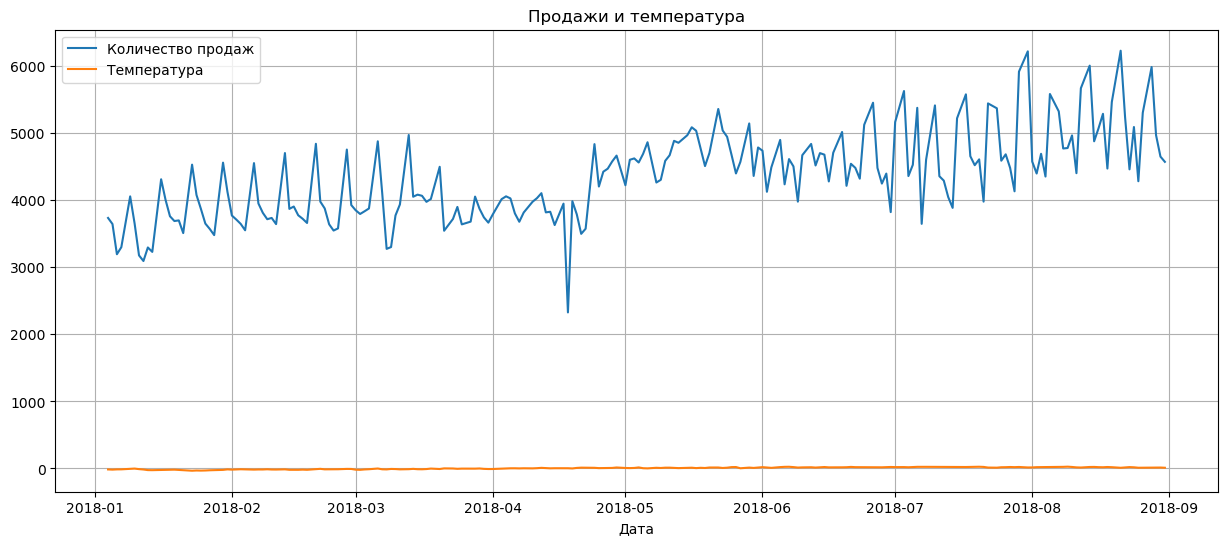

In [53]:
plt.figure(figsize=(15,6))

plt.plot(
    merged_df['Дата'],
    merged_df['Количество продаж'],
    label='Количество продаж'
)

plt.plot(
    merged_df['Дата'],
    merged_df['T'],
    label='Температура'
)

plt.title('Продажи и температура')
plt.xlabel('Дата')

plt.legend()
plt.grid()

plt.show()

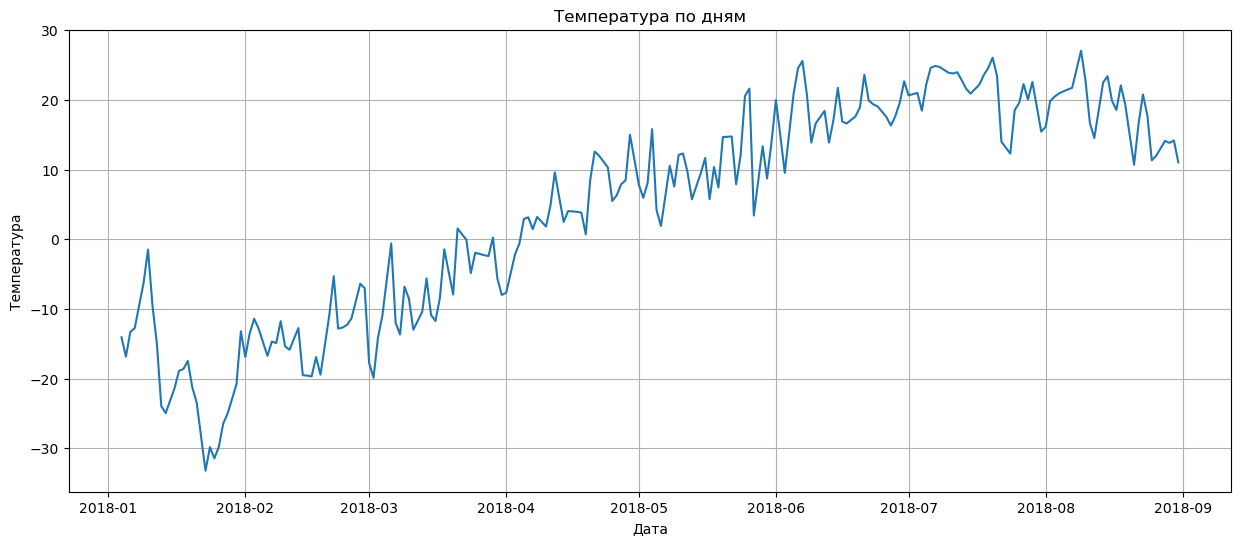

In [52]:
plt.figure(figsize=(15,6))

plt.plot(
    merged_df['Дата'],
    merged_df['T']
)

plt.title('Температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура')

plt.grid()

plt.show()

In [ ]:
Данные о погоде были обработаны и объединены с таблицей продаж по дате

In [ ]:
Построенные графики показывают изменение температуры и продаж по дням

In [ ]:
Температура и продажи меняются со временем, на графике видны рост и снижение показателей